In [167]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bmw-car-sales-dataset/BMW_Car_Sales_Classification.csv


In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

In [169]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "BMW_Car_Sales_Classification.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sumedh1507/bmw-car-sales-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())
df

/tmp/ipython-input-1000000241.py:10: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:       Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume Sales_Classification  
0      151748      98740          8300                 High  
1      121671      79219          3428                  Low  
2       10991     113265          6994                  Low  
3       27255      60971          4047                  Low  
4      122131      49898          3080                  Low  


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


In [170]:
df.isnull().sum()

,0
Model,0
Year,0
Region,0
Color,0
Fuel_Type,0
Transmission,0
Engine_Size_L,0
Mileage_KM,0
Price_USD,0
Sales_Volume,0


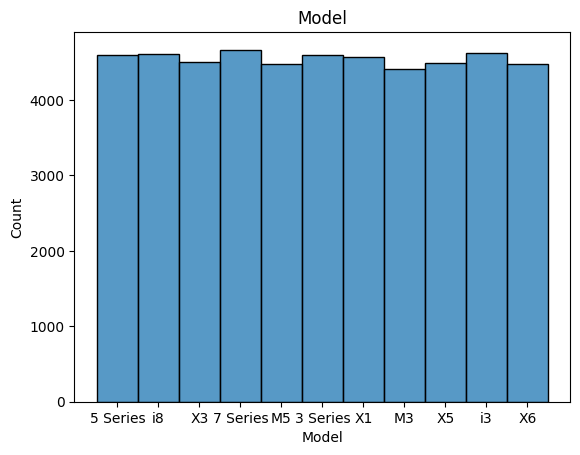

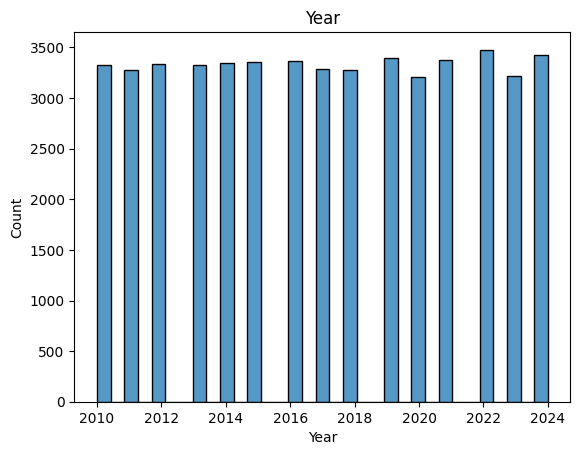

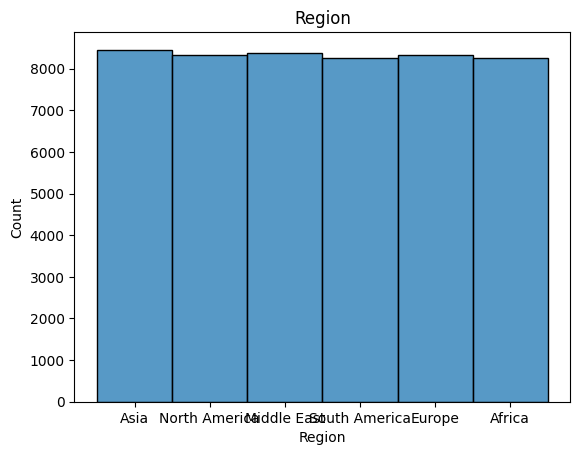

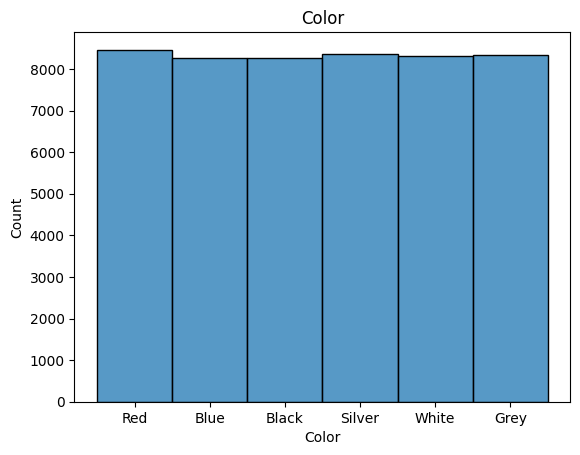

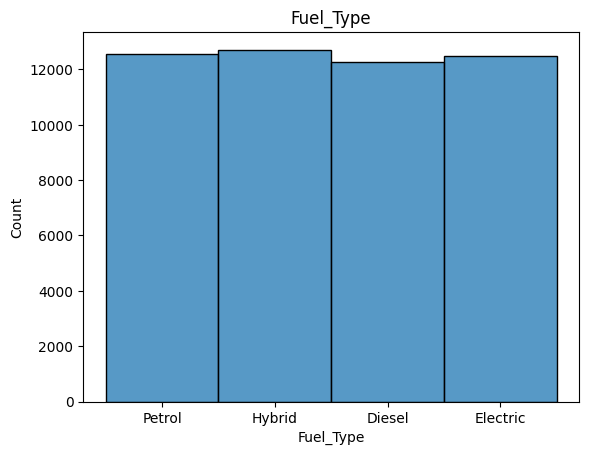

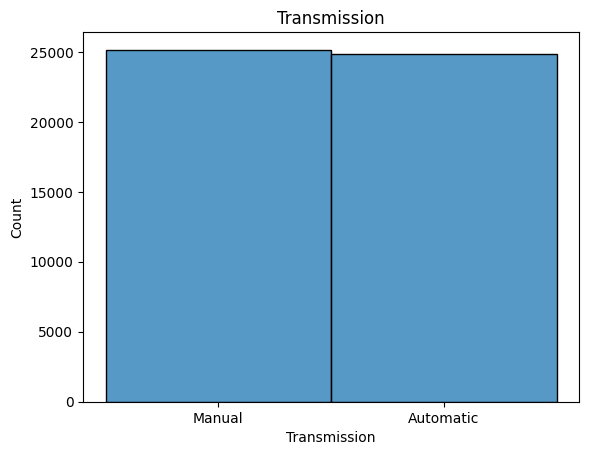

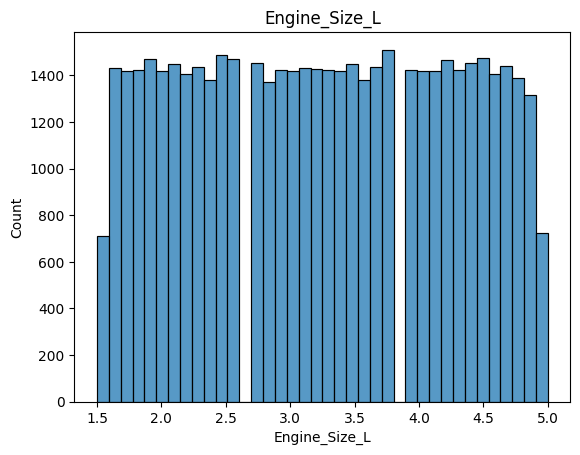

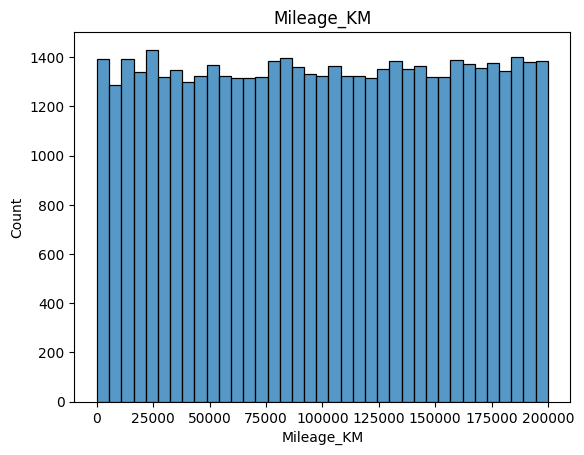

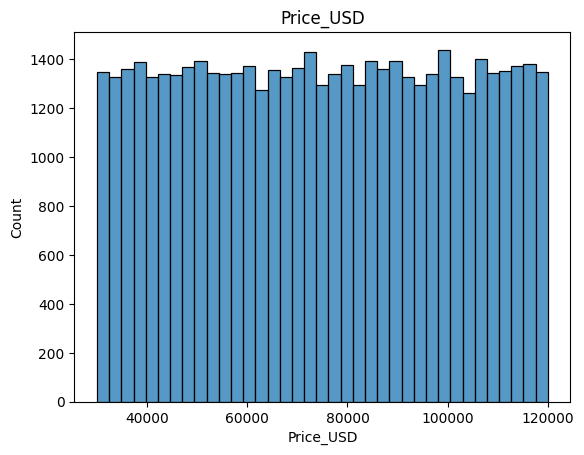

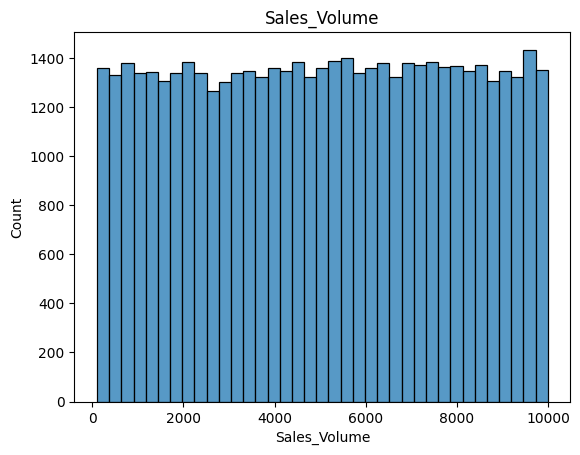

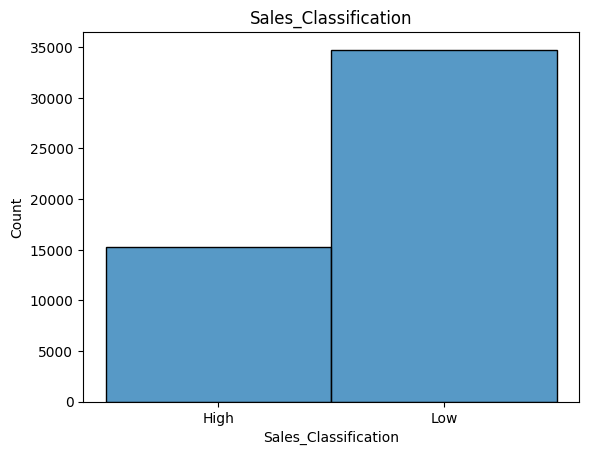

In [171]:
for col in df.columns:
    sns.histplot(df[col])
    plt.title(f'{col}')
    plt.show()

In [172]:
from sklearn.model_selection import train_test_split

In [173]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [174]:
df.Sales_Classification = df.Sales_Classification.map({'High': 1, 'Low': 0})

In [175]:
X = df.drop(columns=['Sales_Classification'], axis=1)
y = df.Sales_Classification

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000, 10), (10000, 10), (40000,), (10000,))

In [176]:
df.Region.value_counts(), df.Color.value_counts(), df.Fuel_Type.value_counts(), df.Transmission.value_counts(), df.Engine_Size_L.value_counts(), df.Mileage_KM.value_counts(), df.Sales_Volume.value_counts()

(Region
 Asia             8454
 Middle East      8373
 North America    8335
 Europe           8334
 Africa           8253
 South America    8251
 Name: count, dtype: int64,
 Color
 Red       8463
 Silver    8350
 Grey      8348
 White     8304
 Black     8273
 Blue      8262
 Name: count, dtype: int64,
 Fuel_Type
 Hybrid      12716
 Petrol      12550
 Electric    12471
 Diesel      12263
 Name: count, dtype: int64,
 Transmission
 Manual       25154
 Automatic    24846
 Name: count, dtype: int64,
 Engine_Size_L
 3.8    1511
 2.5    1486
 4.5    1475
 1.9    1471
 2.6    1470
 4.2    1468
 2.7    1452
 4.4    1452
 3.5    1450
 2.1    1448
 4.7    1442
 3.7    1437
 2.3    1436
 1.6    1432
 3.1    1431
 3.2    1426
 2.9    1425
 3.9    1425
 4.3    1424
 3.3    1423
 1.8    1422
 4.1    1421
 3.0    1420
 3.4    1419
 1.7    1418
 4.0    1418
 2.0    1417
 2.2    1406
 4.6    1405
 4.8    1391
 2.4    1381
 3.6    1381
 2.8    1370
 4.9    1314
 5.0     723
 1.5     710
 Name: count, d

In [177]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform, loguniform
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [178]:
X_train.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
1211,7 Series,2024,South America,Grey,Petrol,Manual,4.1,6373,41921,9249
3819,7 Series,2019,Middle East,Red,Petrol,Automatic,3.7,131975,35333,1784
13492,i8,2012,North America,Blue,Petrol,Automatic,1.6,95338,64455,330
3760,X3,2017,South America,Black,Diesel,Automatic,3.7,127983,98265,8420
38274,3 Series,2014,Africa,White,Hybrid,Automatic,4.1,47097,44635,5511


In [179]:
num_pipe = Pipeline([
    ('std', StandardScaler())
])

cat_pipe = Pipeline([
    ('ohe', OneHotEncoder())
])
transform = ColumnTransformer([
    ('num', num_pipe, ['Mileage_KM', 'Engine_Size_L', 'Sales_Volume', 'Price_USD', 'Year']),
    ('cat', cat_pipe, ['Region', 'Color', 'Fuel_Type', 'Transmission', 'Model'])
])

In [180]:
pipeline = Pipeline([
    ('transform', transform),
    ('logistic', LogisticRegression(random_state=42, class_weight='balanced'))
])

In [181]:
param_grid_1 = {
    'logistic__solver': ['liblinear'],
    'logistic__penalty': ['l1'],
    'logistic__C': [0.01, 0.1, 1],
    'logistic__max_iter': list(range(100, 301, 100))
}

In [182]:
model = GridSearchCV(pipeline, param_grid=param_grid_1, cv=3, scoring='balanced_accuracy', n_jobs=-1, verbose=1)
model.fit(X_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('transform',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('std',
                                                                                          StandardScaler())]),
                                                                         ['Mileage_KM',
                                                                          'Engine_Size_L',
                                                                          'Sales_Volume',
                                                                          'Price_USD',
                                                                          'Year']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder())]),
                                                                         ['Region',
                                                                          'Color',
                                                                          'Fuel_Type',
                                                                          'Transmission',
                                                                          'Model'])])),
                                       ('logistic',
                                        LogisticRegression(class_weight='balanced',
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'logistic__C': [0.01, 0.1, 1],
                         'logistic__max_iter': [100, 200, 300],
                         'logistic__penalty': ['l1'],
                         'logistic__solver': ['liblinear']},
             scoring='balanced_accuracy', verbose=1)

In [183]:
model.score(X_train, y_train), model.score(X_test, y_test)

(np.float64(0.9991367838003093), np.float64(0.9987771543662782))

In [184]:
predict = model.predict(X_test)

In [185]:
print(f'Best Score: {classification_report(y_test, predict)}')

Best Score:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6951
           1       0.99      1.00      1.00      3049

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

